Smart-Retail-Customer-Intelligence-Platform/

data/
    faces/

models/
    face_encodings.pkl

notebooks/
    03_Face_Recognition.ipynb

In [1]:
!pip install face_recognition
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=defd201bb5704374369e4957c8a339da91c7ea8cfcb7e7ceced357b67b686a9b
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [2]:
import cv2
import face_recognition
import numpy as np
import os
import pickle

from google.colab import files

In [3]:
!pip install face_recognition opencv-python scikit-learn joblib

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import joblib

In [5]:
lfw_people = fetch_lfw_people(
    min_faces_per_person=50,
    resize=0.4
)

X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names

print("Number of Images:", X.shape[0])
print("Number of Features:", X.shape[1])
print("Number of Classes:", len(target_names))

Number of Images: 1560
Number of Features: 1850
Number of Classes: 12


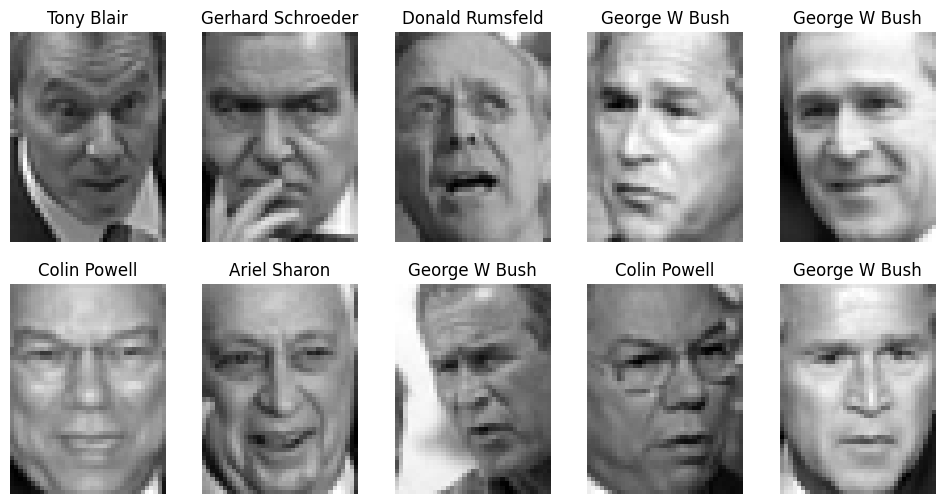

In [6]:
fig, axes = plt.subplots(2,5, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        lfw_people.images[i],
        cmap="gray"
    )
    ax.set_title(target_names[y[i]])
    ax.axis("off")

plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1170, 1850)
(390, 1850)


In [8]:
model = SVC(
    kernel='linear',
    probability=True
)

model.fit(X_train, y_train)

print("Face Recognition Model Trained Successfully!")

Face Recognition Model Trained Successfully!


In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.8051282051282052

Classification Report:

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.81      0.72        16
     Colin Powell       0.81      0.88      0.84        66
  Donald Rumsfeld       0.60      0.78      0.68        27
    George W Bush       0.87      0.84      0.86       140
Gerhard Schroeder       0.69      0.75      0.72        24
      Hugo Chavez       0.92      0.71      0.80        17
   Jacques Chirac       0.80      0.40      0.53        10
    Jean Chretien       0.79      0.79      0.79        14
    John Ashcroft       0.92      0.75      0.83        16
Junichiro Koizumi       0.89      0.73      0.80        11
  Serena Williams       0.86      0.67      0.75         9
       Tony Blair       0.80      0.82      0.81        40

         accuracy                           0.81       390
        macro avg       0.80      0.74      0.76       390
     weighted avg       0.82      0.81      0.81       390


In [10]:
import joblib

joblib.dump(model, "face_recognition_model.pkl")

print("Face Recognition model saved successfully!")

Face Recognition model saved successfully!


In [11]:
from google.colab import files

files.download("face_recognition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Person:", target_names[prediction[0]])
print("Actual Person:", target_names[y_test[0]])

Predicted Person: George W Bush
Actual Person: George W Bush
